---
## Scetion 0: Initial setup

**Imports**

In [1]:
# Imports
import sys
from pathlib import Path

# This notebook only orchestrates. Every function and class it calls lives in the
# `macrocircuits` package under src/ -- read or edit it there.
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import matplotlib.pyplot as plt

# Importing macrocircuits also registers the `swim` and `swim_12_links` tasks with
# the dm_control swimmer suite, which is what lets suite.load() find them below.
from macrocircuits import ensure_tonic

# Clone neuromatch/tonic next to this notebook (once) and put it on the import path.
# It has to run before the tonic-backed imports below (training, models); see
# src/macrocircuits/tonic_setup.py for why tonic isn't a pip install.
ensure_tonic()

# The Swim task rewards swimming forward at _SWIM_SPEED and hides the target the
# stock dm_control swimmer chases.
from macrocircuits.training import play_model, train  # See src/macrocircuits/training.py.
from macrocircuits.plotting import (  # See src/macrocircuits/plotting.py.
    plot_performance,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## Scetion 1: Select parameters

**Parameters**
- Networks used
- Length of the swimmer
- RL Method used
- ...?

In [2]:
# Parameters

---
## Scetion 2: Training

**Training**

In [ ]:
# Training (env.py file)

# MLP
train('import tonic.torch',
      'tonic.torch.agents.PPO(model=ppo_mlp_model(actor_sizes=(256, 256), critic_sizes=(256,256)))',
      'tonic.environments.ControlSuite("swimmer-swim")',
      name = 'new_env_mlp_256',
      trainer = 'tonic.Trainer(steps=int(5e5),save_steps=int(1e5))')


# PJO_NCAP
print("--------------- \n PJO_NCAP Agent Running")
train('import tonic.torch',
      # 'tonic.torch.agents.D4PG(model=d4pg_swimmer_model(n_joints=5,critic_sizes=(128,128)))',
      'tonic.torch.agents.PPO(model=ppo_per_joint_oscillator_model(n_joints=5,critic_sizes=(256,256)))',
  'tonic.environments.ControlSuite("swimmer-swim",time_feature=True)',
  name = 'new_env_pjo_ncap_ppo',
  trainer = 'tonic.Trainer(steps=int(1e5),save_steps=int(5e4))')


# NCAP
print("--------------- \n NCAP Agent Running")
train('import tonic.torch',
      # 'tonic.torch.agents.D4PG(model=d4pg_swimmer_model(n_joints=5,critic_sizes=(128,128)))',
      'tonic.torch.agents.PPO(model=ppo_swimmer_model(n_joints=5,critic_sizes=(256,256)))',
  'tonic.environments.ControlSuite("swimmer-swim",time_feature=True)',
  name = 'new_env_ncap_ppo',
  trainer = 'tonic.Trainer(steps=int(1e5),save_steps=int(5e4))')

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data/local/experiments/tonic/swimmer-swim/new_env_mlp_256/config.yaml
          Time left:  epoch 0:00:00  total 0:15:14          
actor                                                       
  clip fraction                                        0.154
  entropy                                               1.05
  iterations                                            23.8
  kl                                                  0.0107
  loss                                               -0.0173
  std                                                  0.692
  stop                                                0.0316
critic                                                      
  iterations                                              80
  loss                                                  2.54
  v                                                     4.97
test                                                        
  action                                               

In [ ]:
# # Training (old_env.py file)

# # MLP
# train('import tonic.torch',
#       'tonic.torch.agents.PPO(model=ppo_mlp_model(actor_sizes=(256, 256), critic_sizes=(256,256)))',
#       'tonic.environments.ControlSuite("swimmer-swim")',
#       name = 'mlp_256',
#       trainer = 'tonic.Trainer(steps=int(5e5),save_steps=int(1e5))')


# # PJO_NCAP
# print("--------------- \n PJO_NCAP Agent Running")
# train('import tonic.torch',
#       # 'tonic.torch.agents.D4PG(model=d4pg_swimmer_model(n_joints=5,critic_sizes=(128,128)))',
#       'tonic.torch.agents.PPO(model=ppo_per_joint_oscillator_model(n_joints=5,critic_sizes=(256,256)))',
#   'tonic.environments.ControlSuite("swimmer-swim",time_feature=True)',
#   name = 'pjo_ncap_ppo',
#   trainer = 'tonic.Trainer(steps=int(1e5),save_steps=int(5e4))')


# # NCAP
# print("--------------- \n NCAP Agent Running")
# train('import tonic.torch',
#       # 'tonic.torch.agents.D4PG(model=d4pg_swimmer_model(n_joints=5,critic_sizes=(128,128)))',
#       'tonic.torch.agents.PPO(model=ppo_swimmer_model(n_joints=5,critic_sizes=(256,256)))',
#   'tonic.environments.ControlSuite("swimmer-swim",time_feature=True)',
#   name = 'ncap_ppo',
#   trainer = 'tonic.Trainer(steps=int(1e5),save_steps=int(5e4))')

--------------- 
 PJO_NCAP Agent Running


/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data/local/experiments/tonic/swimmer-swim/pjo_ncap_ppo/config.yaml
          Time left:  epoch 0:00:00  total 0:02:13          
actor                                                       
  clip fraction                                       0.0194
  entropy                                             -0.884
  iterations                                              80
  kl                                                 0.00421
  loss                                              -0.00157
  std                                                    0.1
  stop                                                     0
critic                                                      
  iterations                                              80
  loss                                                  68.4
  v                                                     35.6
test                                                        
  action                                                  

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data/local/experiments/tonic/swimmer-swim/ncap_ppo/config.yaml
          Time left:  epoch 0:00:00  total 0:01:53          
actor                                                       
  clip fraction                                       0.0127
  entropy                                             -0.884
  iterations                                              80
  kl                                                 0.00247
  loss                                             -0.000903
  std                                                    0.1
  stop                                                     0
critic                                                      
  iterations                                              80
  loss                                                  50.6
  v                                                     33.5
test                                                        
  action                                                    
 

---
## Scetion 3: Visualization

**Visualization of the rewards and the behaviour**

In [4]:
# Visualization

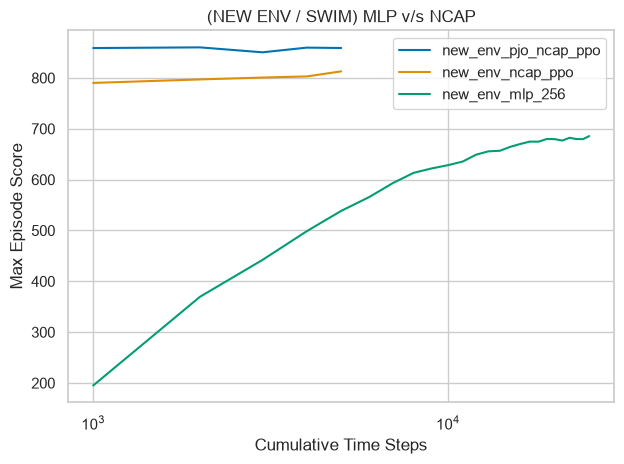

In [8]:
# rerun this cell if it displays moret than the graphs
%matplotlib inline
fig, ax = plt.subplots()

#Replace the paths with the path to models you trained to plot their performance.
paths = [
    'data/local/experiments/tonic/swimmer-swim/new_env_pjo_ncap_ppo',
    'data/local/experiments/tonic/swimmer-swim/new_env_ncap_ppo',
    'data/local/experiments/tonic/swimmer-swim/new_env_mlp_256'
]
plot_performance(paths, ax=ax, title='(NEW ENV / SWIM) MLP v/s NCAP')
plt.tight_layout()
plt.show()

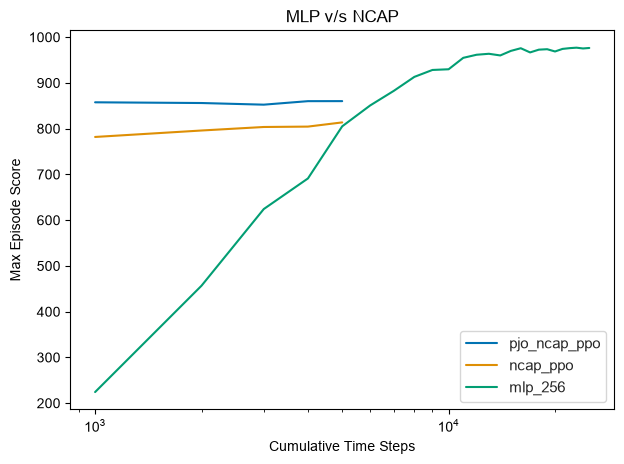

In [5]:
# rerun this cell if it displays moret than the graphs
%matplotlib inline
fig, ax = plt.subplots()

#Replace the paths with the path to models you trained to plot their performance.
paths = [
    'data/local/experiments/tonic/swimmer-swim/pjo_ncap_ppo',
    'data/local/experiments/tonic/swimmer-swim/ncap_ppo',
    'data/local/experiments/tonic/swimmer-swim/mlp_256'
]
plot_performance(paths, ax=ax, title='MLP v/s NCAP')
plt.tight_layout()
plt.show()

In [6]:
play_model('data/local/experiments/tonic/swimmer-swim/mlp_256')

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-swim/mlp_256/checkpoints/step_500000.pt
Reward for the run:  987.0237


In [7]:
play_model('data/local/experiments/tonic/swimmer-swim/ncap_ppo')

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-swim/ncap_ppo/checkpoints/step_100000.pt
Reward for the run:  821.2766


In [8]:
play_model('data/local/experiments/tonic/swimmer-swim/pjo_ncap_ppo')

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-swim/pjo_ncap_ppo/checkpoints/step_100000.pt
Reward for the run:  867.0041
